In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder,StandardScaler,OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression

In [2]:
df= pd.read_csv('Toyota_Corolla.csv')
df.shape

(1436, 11)

In [3]:
df.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


In [5]:
### performing EDA 
### finding missing values
df.isnull().sum()

Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64

##### Hence we can conclude that there are no missing values

In [6]:
### finding duplicates
df.duplicated().sum()

np.int64(1)

In [7]:
## there is 1 duplicate value in the dataset, we can drop the duplcate using drop()
df.drop_duplicates(inplace=True,ignore_index=True)
df.duplicated().sum()

np.int64(0)

##### The duplicate value in the dataset is dropped permanently using inplace=True

<Axes: >

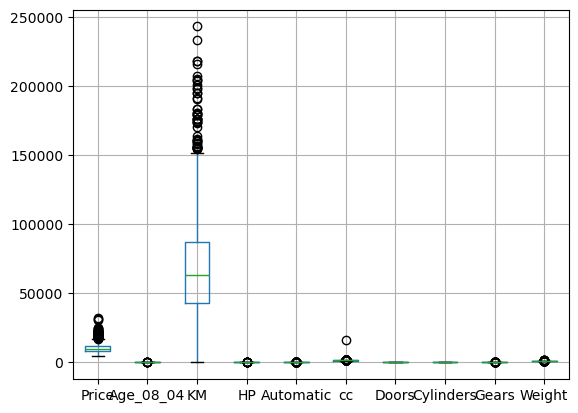

In [8]:
### checking for outliers
df.boxplot()

In [9]:
### outliers are present in the dataset,these outliers can be removed using capping technique
def outlier_cappping(df,column):
    Q1= df[column].quantile(0.25)
    Q3= df[column].quantile(0.75)
    IQR= Q3-Q1
    lower_extreme= Q1-1.5*IQR
    upper_extreme= Q3+1.5*IQR
    df[column]=df[column].apply(lambda x: lower_extreme if x<lower_extreme else upper_extreme if x>upper_extreme else x)
for col in df.select_dtypes(['int','float']).columns:
    outlier_cappping(df,col)

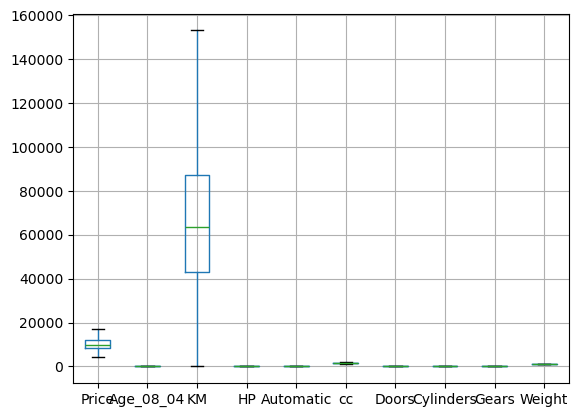

In [10]:
df.boxplot()
plt.show()

In [11]:
one_hot=OneHotEncoder()
df1=pd.DataFrame(one_hot.fit_transform(df[['Fuel_Type']]).toarray())

In [12]:
df2=df.join(df1)
df2

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight,0,1,2
0,13500.0,23.0,46986.0,Diesel,90.0,0.0,1900.0,3,4,5.0,1152.5,0.0,1.0,0.0
1,13750.0,23.0,72937.0,Diesel,90.0,0.0,1900.0,3,4,5.0,1152.5,0.0,1.0,0.0
2,13950.0,24.0,41711.0,Diesel,90.0,0.0,1900.0,3,4,5.0,1152.5,0.0,1.0,0.0
3,14950.0,26.0,48000.0,Diesel,90.0,0.0,1900.0,3,4,5.0,1152.5,0.0,1.0,0.0
4,13750.0,30.0,38500.0,Diesel,90.0,0.0,1900.0,3,4,5.0,1152.5,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1430,7500.0,69.0,20544.0,Petrol,86.0,0.0,1300.0,3,4,5.0,1025.0,0.0,0.0,1.0
1431,10845.0,72.0,19000.0,Petrol,86.0,0.0,1300.0,3,4,5.0,1015.0,0.0,0.0,1.0
1432,8500.0,71.0,17016.0,Petrol,86.0,0.0,1300.0,3,4,5.0,1015.0,0.0,0.0,1.0
1433,7250.0,70.0,16916.0,Petrol,86.0,0.0,1300.0,3,4,5.0,1015.0,0.0,0.0,1.0


In [13]:
df2.columns

Index([    'Price', 'Age_08_04',        'KM', 'Fuel_Type',        'HP',
       'Automatic',        'cc',     'Doors', 'Cylinders',     'Gears',
          'Weight',           0,           1,           2],
      dtype='object')

In [14]:
### now changing the column names
df2.rename(columns={0:'Diesel',1:'Petrol',2:'CNG'},inplace=True)

In [15]:
### AS the previous categorical column is converted to numerical format and we are no more in need of the Fuel_Type categorical colum
### we can drop this column permanently using Inplace()
df2.drop(columns=['Fuel_Type'],inplace=True)
df2

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight,Diesel,Petrol,CNG
0,13500.0,23.0,46986.0,90.0,0.0,1900.0,3,4,5.0,1152.5,0.0,1.0,0.0
1,13750.0,23.0,72937.0,90.0,0.0,1900.0,3,4,5.0,1152.5,0.0,1.0,0.0
2,13950.0,24.0,41711.0,90.0,0.0,1900.0,3,4,5.0,1152.5,0.0,1.0,0.0
3,14950.0,26.0,48000.0,90.0,0.0,1900.0,3,4,5.0,1152.5,0.0,1.0,0.0
4,13750.0,30.0,38500.0,90.0,0.0,1900.0,3,4,5.0,1152.5,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1430,7500.0,69.0,20544.0,86.0,0.0,1300.0,3,4,5.0,1025.0,0.0,0.0,1.0
1431,10845.0,72.0,19000.0,86.0,0.0,1300.0,3,4,5.0,1015.0,0.0,0.0,1.0
1432,8500.0,71.0,17016.0,86.0,0.0,1300.0,3,4,5.0,1015.0,0.0,0.0,1.0
1433,7250.0,70.0,16916.0,86.0,0.0,1300.0,3,4,5.0,1015.0,0.0,0.0,1.0


## Need to build a model that predicts price of toyota corolla

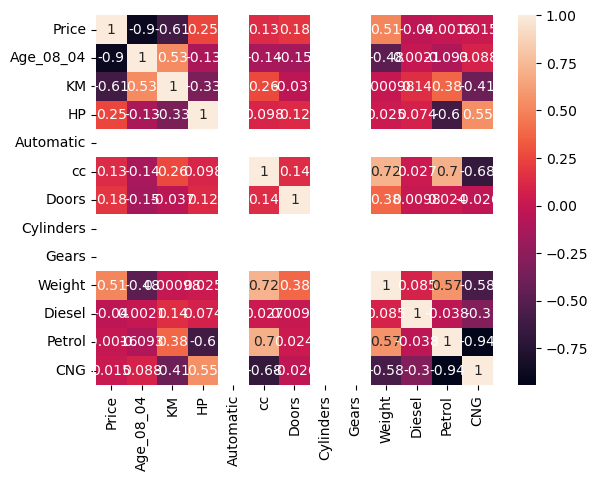

In [17]:
#### Feature selection
corr=df2.corr()
sns.heatmap(corr,annot=True)
plt.show()

In [18]:
from sklearn.feature_selection import f_regression
target= df2[['Price']]
features= df2.drop(columns=['Price'])
features.columns

Index(['Age_08_04', 'KM', 'HP', 'Automatic', 'cc', 'Doors', 'Cylinders',
       'Gears', 'Weight', 'Diesel', 'Petrol', 'CNG'],
      dtype='object')

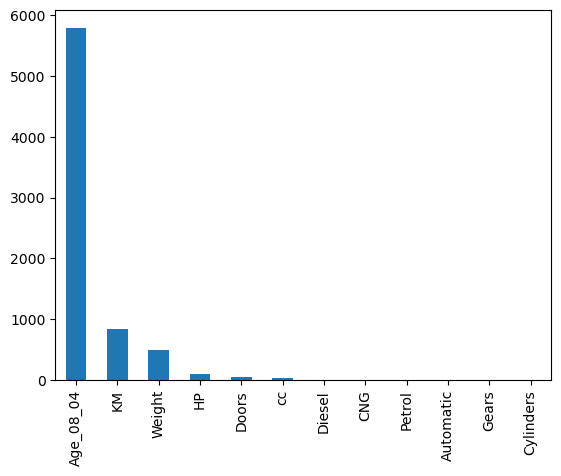

In [19]:
f_reg=f_regression(features,target)
pd.Series(f_reg[0],index=features.columns).sort_values(ascending=False).plot(kind='bar')
plt.show()

In [20]:
### to check multicolinearity(how much the features are dependent upon eachother)
## use Variance Inflation Factor


In [21]:
#### Multicolinearity
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [22]:
features.columns

Index(['Age_08_04', 'KM', 'HP', 'Automatic', 'cc', 'Doors', 'Cylinders',
       'Gears', 'Weight', 'Diesel', 'Petrol', 'CNG'],
      dtype='object')

In [23]:
features.values

array([[2.3000e+01, 4.6986e+04, 9.0000e+01, ..., 0.0000e+00, 1.0000e+00,
        0.0000e+00],
       [2.3000e+01, 7.2937e+04, 9.0000e+01, ..., 0.0000e+00, 1.0000e+00,
        0.0000e+00],
       [2.4000e+01, 4.1711e+04, 9.0000e+01, ..., 0.0000e+00, 1.0000e+00,
        0.0000e+00],
       ...,
       [7.1000e+01, 1.7016e+04, 8.6000e+01, ..., 0.0000e+00, 0.0000e+00,
        1.0000e+00],
       [7.0000e+01, 1.6916e+04, 8.6000e+01, ..., 0.0000e+00, 0.0000e+00,
        1.0000e+00],
       [7.6000e+01, 1.0000e+00, 1.1000e+02, ..., 0.0000e+00, 0.0000e+00,
        1.0000e+00]])

In [24]:
vif= pd.DataFrame()
vif['Features']= features.columns

In [25]:
vif['VIF']= [variance_inflation_factor(features.values,i) for i in range(len(features.columns))]

In [26]:
vif.sort_values(by='VIF',ascending=False)

,Features,VIF
9,Diesel,inf
11,CNG,inf
10,Petrol,inf
4,cc,12.807789
2,HP,10.104386
8,Weight,3.853438
0,Age_08_04,2.181306
1,KM,2.015390
5,Doors,1.302842
7,Gears,0.000000


In [28]:
###  the columns with less relationship are dropped

In [29]:
features.drop(columns=['Diesel','CNG','Petrol','Automatic','Gears','Cylinders','cc'],inplace=True)

In [30]:
features.head()

,Age_08_04,KM,HP,Doors,Weight
0,23.0,46986.0,90.0,3,1152.5
1,23.0,72937.0,90.0,3,1152.5
2,24.0,41711.0,90.0,3,1152.5
3,26.0,48000.0,90.0,3,1152.5
4,30.0,38500.0,90.0,3,1152.5


## Summary

### Spliting the dataset

In [35]:
### taking 80% of the daya as the training dtata
x_train,x_test,y_train,y_test=train_test_split(features,target,train_size=0.8,random_state=100)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(1148, 5)
(287, 5)
(1148, 1)
(287, 1)


In [36]:
x_train.head()

,Age_08_04,KM,HP,Doors,Weight
108,20.0,7187.0,110.0,3,1105.0
1279,78.0,73638.0,86.0,4,1015.0
857,62.0,64797.0,110.0,5,1075.0
902,65.0,59000.0,110.0,5,1075.0
372,33.0,16512.0,97.0,5,1085.0


In [39]:
### Applying scaling on features
### Here Age_08_04,KM,HP and Weight are continuous , Hence we can apply Standard Scaler
std_sca=StandardScaler()
x_train[['Age_08_04','KM','HP','Weight']]=std_sca.fit_transform(x_train[['Age_08_04','KM','HP','Weight']])

In [40]:
### Original value sare scaled and replaced
x_train.head()

,Age_08_04,KM,HP,Doors,Weight
108,-1.940533,-1.748188,0.689004,3,0.954608
1279,1.182405,0.176456,-1.123604,4,-1.387370
857,0.320905,-0.079609,0.689004,5,0.173948
902,0.482436,-0.247509,0.689004,5,0.173948
372,-1.240564,-1.478104,-0.292825,5,0.434168


In [41]:
### for x_test we only use .transform as it gets its mean and std-dev vales from x_train
std_sca.transform(x_test[['Age_08_04','KM','HP','Weight']])

array([[-1.61747011, -0.71092313, -0.29282507,  1.08471757],
       [ 0.32090502, -0.82677654,  0.68900404,  0.17394831],
       [-1.13287633, -1.26090825, -0.29282507, -1.12715062],
       ...,
       [-1.83284513, -1.07586138, -0.29282507,  1.08471757],
       [-0.43290753, -0.48017209, -0.29282507, -0.21638137],
       [ 0.37474877, -0.29347431,  0.46242809,  1.21482746]])

In [42]:
x_test[['Age_08_04','KM','HP','Weight']]=std_sca.transform(x_test[['Age_08_04','KM','HP','Weight']])

In [43]:
x_test.head()

,Age_08_04,KM,HP,Doors,Weight
57,-1.617470,-0.710923,-0.292825,5,1.084718
1002,0.320905,-0.826777,0.689004,5,0.173948
360,-1.132876,-1.260908,-0.292825,3,-1.127151
903,0.267061,-0.247509,0.689004,5,0.043838
1276,1.236249,0.189634,0.689004,5,0.173948


In [57]:
### model training using all features
lin_model_1=LinearRegression()
lin_model_1.fit(x_train,y_train)

LinearRegression()

In [58]:
b1=lin_model_1.coef_

In [59]:
b0=lin_model_1.intercept_

In [60]:
### training validation
y_pred=lin_model_1.predict(x_train)
r2_score(y_train,y_pred)

0.8607158002042327

In [61]:
### testing validation
y_pred1=lin_model_1.predict(x_test)
r2_score(y_test,y_pred1)

0.8432949461521851

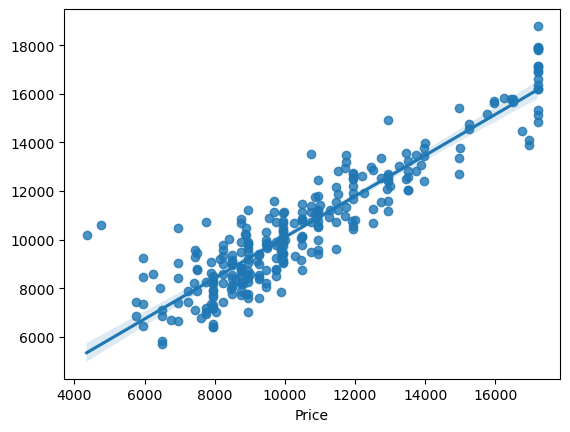

In [50]:
#### Regression plot
sns.regplot(x=y_test,y=y_pred1)
plt.show()

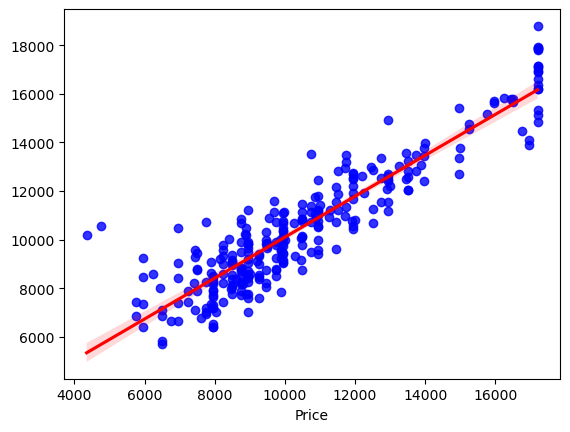

In [51]:
sns.regplot(x=y_test,y=y_pred1,scatter_kws={'color':'Blue'},line_kws={'color':'red'})
plt.show()

Building 3 MLR models requires selection of 3 different combinations of independent variables from the training dataset

In [56]:
### Selecting features for model 2
features_2=['Age_08_04','KM','HP']
x_train_2=x_train[features_2]
x_test_2=x_test[features_2]

In [62]:
#### Building the model and training the model as per new training dataset
lin_model_2=LinearRegression()
lin_model_2.fit(x_train_2,y_train)

LinearRegression()

In [70]:
b1_2=lin_model_1.coef_

In [71]:
b0_2=lin_model_1.intercept_

In [72]:
print(b1_2,b0_2)

[[-2009.04937993  -648.97354516   269.34706974    -5.45873786
    590.21088226]] [10510.84399839]


In [84]:
### training validation for model 2
y_pred2=lin_model_2.predict(x_train_2)
r2_score(y_train,y_pred2)

0.8359673756752722

In [85]:
###testing validation for model 2
y_pred3=lin_model_2.predict(x_test_2)
r2_score(y_test,y_pred3)

0.8320996621870318

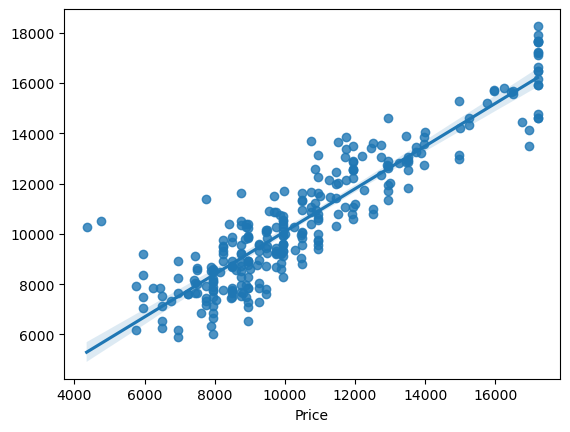

In [88]:
### Regression plot
sns.regplot(x=y_test,y=y_pred3)
plt.show()

In [78]:
#### Selecting features for model 3
features_3=['Age_08_04','KM','Weight']
x_train_3=x_train[features_3]
x_test_3=x_test[features_3]

In [79]:
#### Building the model and training the model as per new training dataset
lin_model_3=LinearRegression()
lin_model_3.fit(x_train_3,y_train)

LinearRegression()

In [80]:
b1_3=lin_model.coef_

In [81]:
b0_3=lin_model.intercept_

In [86]:
### training validation for model 2
y_pred4=lin_model_3.predict(x_train_3)
r2_score(y_train,y_pred4)

0.8536223663894826

In [87]:
### testing validation for model 3
y_pred5=lin_model_3.predict(x_test_3)
r2_score(y_test,y_pred5)

0.8351036244654845

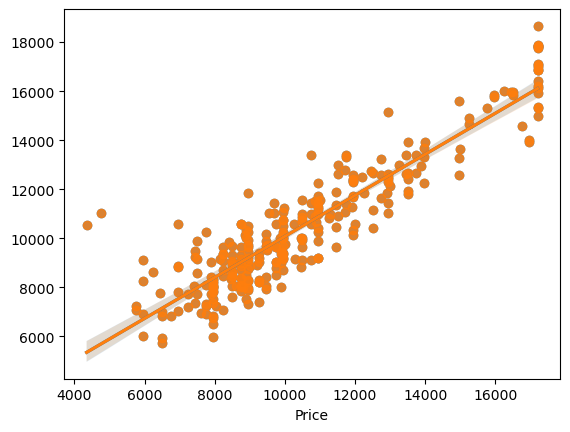

In [91]:
### Regression plt
sns.regplot(x=y_test,y=y_pred5)
plt.show()

#### Evaluate the performance of the model using appropriate evaluation metrics on the testing dataset.

In [92]:
from sklearn.metrics import mean_absolute_error,mean_absolute_percentage_error,mean_squared_error

### Evaluation metrics for model 1 which consists of all the features selected as variables

In [95]:
### Mean Squared Error
mse=mean_squared_error(y_test,y_pred1)
mse

1327867.3341923703

In [96]:
## root mean squared error
rmse=np.sqrt(mse)
rmse

np.float64(1152.3312606157876)

In [97]:
### Mean absolute error
mae=mean_absolute_error(y_test,y_pred1)
mae

856.0691010342935

In [98]:
### Mean absolute percentage error
mape=mean_absolute_percentage_error(y_test,y_pred1)*100
mape

9.287469627266857

In [99]:
r_squared=r2_score(y_test,y_pred1)
r_squared

0.8432949461521851

### As the value of the r_squared is approximately equal to 1, we can say that the model is good

In [102]:
features.shape

(1435, 5)

In [103]:
N=1435
k=5

In [104]:
### Adjusted R2
adj_r= 1-(((1-r_squared)*(N-1))/(N-k-1))
adj_r

0.842746642954677

In [105]:
r_squared-adj_r

0.0005483031975080932

### Similarly calculating the evaluation metrics for model 2 testing dataset


In [107]:
### Mean Squared Error
mse=mean_squared_error(y_test,y_pred3)
mse

1422732.5061144691

In [108]:
## root mean squared error
rmse=np.sqrt(mse)
rmse

np.float64(1192.7835118387868)

In [109]:
### Mean absolute error
mae=mean_absolute_error(y_test,y_pred3)
mae

904.4241955479325

In [110]:
### Mean absolute percentage error
mape=mean_absolute_percentage_error(y_test,y_pred3)*100
mape

9.68450162854256

In [111]:
r_squared=r2_score(y_test,y_pred3)
r_squared

0.8320996621870318

In [112]:
### As the value of r_squared is approximately nearer to 1, the model is good

#### Applying Lasso and Ridge methods on the model.

In [114]:
from sklearn.linear_model import Lasso,Ridge,ElasticNet,LassoCV,RidgeCV ,ElasticNetCV

In [120]:
### Applying Lasso Regularization Technique on model 1
### taking alpha randomly
lasso=Lasso(alpha=1,max_iter=1000)
lasso.fit(x_train,y_train)
y_pred=lasso.predict(x_test)
r2_score(y_test,y_pred1)

0.8432949461521851

In [122]:
### so as to find best alpha value and do validation we use lassoCV package
lassocv=LassoCV(n_alphas=100,max_iter=1000,cv=5)
lassocv.fit(x_train,y_train)

LassoCV(cv=5)

In [123]:
lassocv.alphas_

array([2682.36957362, 2501.58684194, 2332.98826131, 2175.75266074,
       2029.11421339, 1892.35870662, 1764.8200633 , 1645.87709768,
       1534.95048985, 1431.49996414, 1335.02165762, 1245.04566606,
       1161.13375519, 1082.87722627, 1009.89492548,  941.8313875 ,
        878.35510418,  819.15690991,  763.94847581,  712.46090538,
        664.44342489,  619.66216186,  577.89900609,  538.95054724,
        502.62708416,  468.75170092,  437.15940514,  407.69632435,
        380.2189566 ,  354.59347148,  330.69505828,  308.40731815,
        287.62169711,  268.23695736,  250.15868419,  233.29882613,
        217.57526607,  202.91142134,  189.23587066,  176.48200633,
        164.58770977,  153.49504899,  143.14999641,  133.50216576,
        124.50456661,  116.11337552,  108.28772263,  100.98949255,
         94.18313875,   87.83551042,   81.91569099,   76.39484758,
         71.24609054,   66.44434249,   61.96621619,   57.78990061,
         53.89505472,   50.26270842,   46.87517009,   43.71594

In [124]:
lassocv.coef_

array([-2009.08432071,  -635.21940666,   256.38811948,     0.        ,
         571.18849869])

In [127]:
### to find mean value for alphas
mse=lassocv.mse_path_

In [129]:
### the best alphas will have the less mse 
mse=lassocv.mse_path_.mean(axis=1)
best_alpha=lassocv.alpha_
best_alpha

np.float64(17.64820063297565)

In [130]:
### Applying Ridge for the model
ridge=Ridge(alpha=1,max_iter=100)
ridge.fit(x_train,y_train)
y_pred= ridge.predict(x_test)
r2_score(y_test,y_pred1)

0.8432949461521851

In [134]:
ridgecv.coef_

array([-2003.91453649,  -650.72609075,   268.83933918,    -5.16078313,
         591.67091894])

In [131]:
ridgecv=RidgeCV(alphas=(0.1,2,10,20,15,100),cv=5)
ridgecv.fit(x_train,y_train)

RidgeCV(alphas=(0.1, 2, 10, 20, 15, 100), cv=5)

In [133]:
ridgecv.alpha_

np.float64(2.0)

### This implies that among all the provided alpha values the best alpha is 2.0

#### Interview Questions:
##### 1.What is Normalization & Standardization and how is it helpful?
##### Normalization
it is the technique which rescales the data between a specific range, typically [0, 1].
Formula (Min-Max Normalization): Xnorm = X - Xmin / Xmax - Xmin
When to Use:
When features have different scales and you want them in the same range.
Especially useful for distance-based algorithms (like KNN, K-Means, SVM).
##### Standardization
It is the technique to bring the data into a particular range. It transforms data to have zero mean and Standard deviation of 1 (standard normal distribution).
Formula (Z-score Standardization): Xstd = X - μ / σ
Where:
μ is the mean of the feature
σ is the standard deviation

When to Use:
When features have different means and variances
Preferred for many ML algorithms: Linear Regression, Logistic Regression, PCA, etc.


#### 2.What techniques can be used to address multicollinearity in multiple linear regression?
Remove highly correlated independent variables using correlation matrix or VIF
Use Variance Inflation Factor (VIF) to detect multicollinearity
Apply Standardization to reduce numerical instability
Use Principal Component Analysis (PCA) to convert correlated variables into uncorrelated components
Apply Ridge Regression (L2) to shrink coefficients
Use Lasso Regression (L1) for feature selection
Use Elastic Net for highly correlated predictors